# 04 - TF-IDF
Term Frequency-Inverse Document Frequency (TF-IDF) feature extraction on M-Tix reviews.

**TF-IDF** measures how important a word is in a document relative to the entire corpus.
- **TF (Term Frequency):** how often a word appears in a document
- **IDF (Inverse Document Frequency):** penalizes words that appear in many documents

In [4]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

## 1. Load Preprocessed Data

In [6]:
df = pd.read_csv('../data/preprocessed/mtix_preprocessed.csv')
df['stemmed'] = df['stemmed'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['clean_text'] = df['stemmed'].apply(lambda x: ' '.join(x))
print(f'Loaded {len(df)} rows')
df[['content', 'clean_text', 'label']].head()

Loaded 17311 rows


,content,clean_text,label
0,sangat memudahkan,mudah,1
1,seru,seru,1
2,oke,oke,1
3,lebih gampamg pesan,gampamg pesan,1
4,alhamdulillah sdh diuinstall. aplikasi gk berg...,alhamdulillah sdh diuinstall aplikasi gk guna ...,0


## 2. TF-IDF Vectorization

In [7]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

print('TF-IDF Matrix Shape:', X_tfidf.shape)
print('Sample Features:', tfidf.get_feature_names_out()[:10])

TF-IDF Matrix Shape: (17311, 5000)
Sample Features: ['00' '000' '000rupiahs' '005' '01' '05' '06' '06022025' '08' '09']


## 3. Top TF-IDF Words

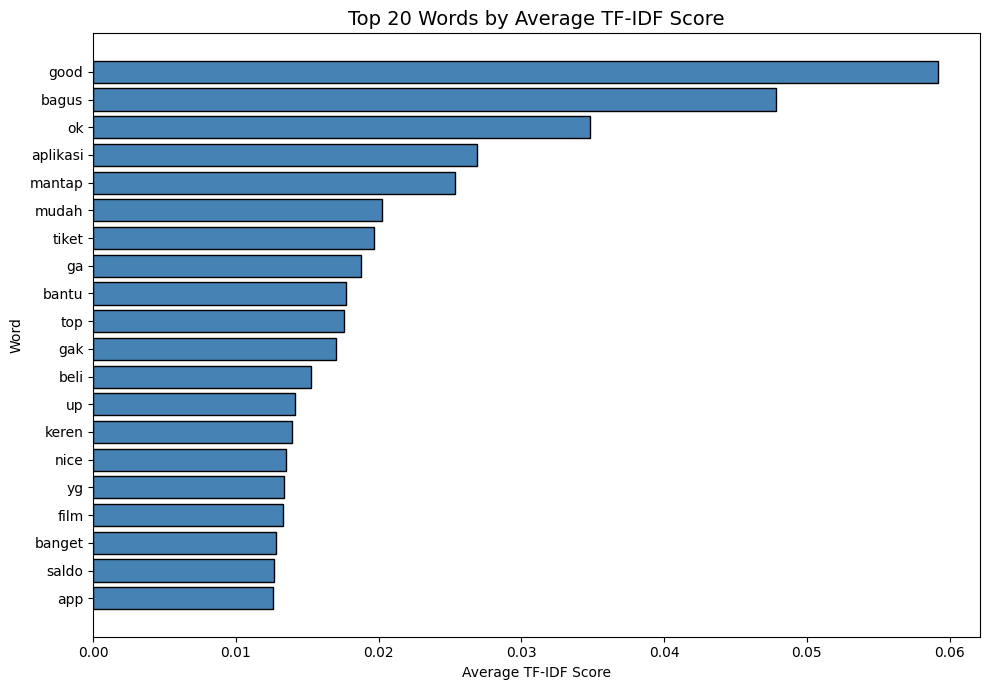

In [8]:
# Average TF-IDF score per word across all documents
avg_tfidf = X_tfidf.mean(axis=0).A1
feature_names = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame({'word': feature_names, 'avg_tfidf': avg_tfidf})
tfidf_df = tfidf_df.sort_values('avg_tfidf', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(tfidf_df['word'][::-1], tfidf_df['avg_tfidf'][::-1], color='steelblue', edgecolor='black')
plt.title('Top 20 Words by Average TF-IDF Score', fontsize=14)
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

## 4. TF-IDF by Sentiment

In [9]:
for label, name in [(1, 'Positive'), (0, 'Negative')]:
 subset = df[df['label'] == label]['clean_text']
 tfidf_sub = TfidfVectorizer(max_features=1000)
 X_sub = tfidf_sub.fit_transform(subset)
 avg = X_sub.mean(axis=0).A1
 feat = tfidf_sub.get_feature_names_out()
 top = pd.DataFrame({'word': feat, 'score': avg}).sort_values('score', ascending=False).head(10)
 print(f'\n--- Top 10 TF-IDF for {name} reviews ---')
 print(top.to_string(index=False))


--- Top 10 TF-IDF for Positive reviews ---
    word    score
    good 0.102501
   bagus 0.075874
      ok 0.060379
  mantap 0.044528
   mudah 0.031360
   bantu 0.029114
   keren 0.023975
    nice 0.023277
aplikasi 0.020932
   tiket 0.017897

--- Top 10 TF-IDF for Negative reviews ---
    word    score
aplikasi 0.044111
      ga 0.038652
     gak 0.033299
     top 0.028602
      up 0.028336
   tiket 0.027710
    buka 0.026502
   saldo 0.026382
    beli 0.023566
      yg 0.023239
